# Análisis de Torneo de Fútbol - Validación de Hipótesis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from soccer_sim import Team, Tournament

np.random.seed(42)
N_SIMULATIONS = 1000
BASE_STRENGTH = 75

## Ejecución de Simulaciones

In [2]:
def run_simulations(n_simulations):
    base_teams = [Team(f"T{i}", np.random.randint(-40, 95)) for i in range(16)]
    all_results = []
    
    for _ in range(n_simulations):
        teams = [Team(t.name, t.base_strength) for t in base_teams]
        tournament = Tournament(
            teams,
            fatigue_effect=0.04,   # +4% fatiga por partido
            injury_prob=0.03,      # 3% probabilidad de lesión
            group_size=4
        )
        tournament.run()
        all_results.append(tournament.sim_result)
    
    return all_results

def process_results(results):
    match_data = []
    penalty_data = []
    team_data = []
    
    for res in results:
        for match in res.match_data:
            match_data.append({
                "Style_A": match.style_a,
                "Style_B": match.style_b,
                "Goals_A": match.goals_a,
                "Goals_B": match.goals_b,
                "Stage": match.stage
            })
            
        for penalty in res.penalty_data:
            penalty_data.append({
                "Skill_A": penalty.skill_a,
                "Skill_B": penalty.skill_b,
                "Winner_Skill": penalty.skill_a if penalty.winner == penalty.team_a else penalty.skill_b
            })
            
        for team in res.team_records:
            team_data.append({
                "Team": team.name,
                "Attack": team.attack_strength,
                "Defense": team.defense_strength,
                "Style": team.play_style,
                "Consistency": team.consistency,
                "Penalty_Skill": team.penalty_skill,
                "Stage": team.stage_reached,
                "Fatigue": team.fatigue * 100,
                "Injuries": team.injuries,
                "Points": team.points
            })
    
    return pd.DataFrame(match_data), pd.DataFrame(penalty_data), pd.DataFrame(team_data)


# Ejecutar simulaciones

In [3]:
print("⚽ Ejecutando simulaciones...")
results = run_simulations(N_SIMULATIONS)
print("✅ Simulaciones completadas!")

# Procesar datos
match_df, penalty_df, team_df = process_results(results)

⚽ Ejecutando simulaciones...
✅ Simulaciones completadas!


## Análisis y Corrección de Datos

En esta sección realizaremos un análisis de la normalidad de los datos y sus correlaciones para validar los supuestos estadísticos de nuestro modelo.

### Análisis de QQ-Plot

Los gráficos QQ-Plot nos permiten visualizar qué tan cerca están nuestros datos de una distribución normal.

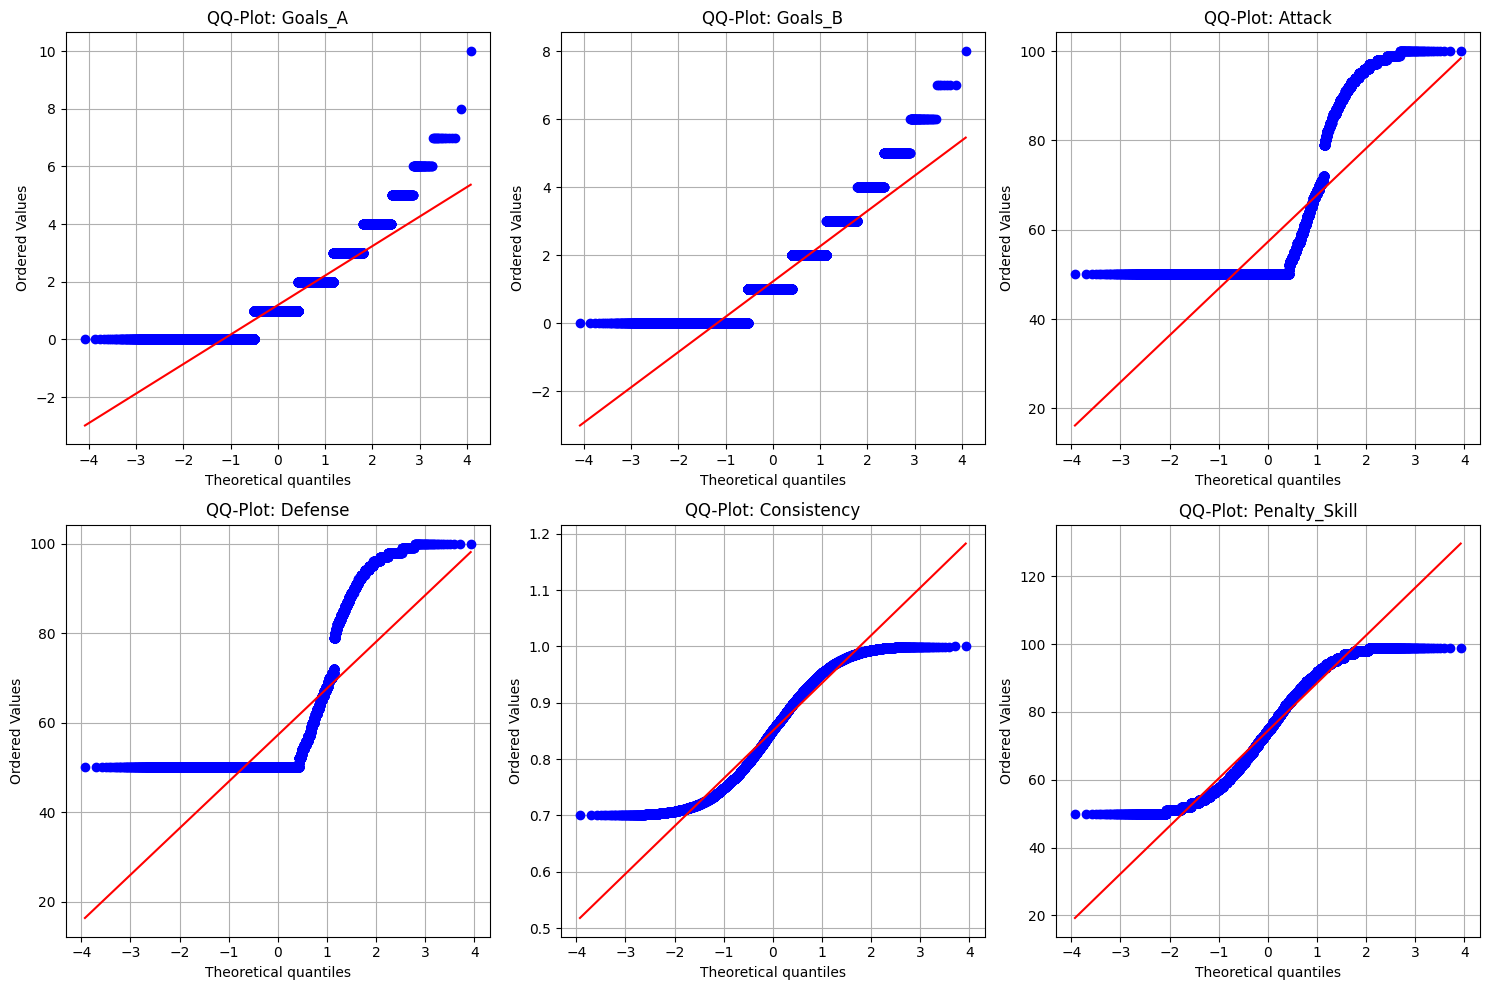

In [5]:
# Creamos QQ-Plots para variables seleccionadas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, data) in enumerate(list(numeric_data.items())[:6]):  # Tomamos las primeras 6 variables
    stats.probplot(data, dist="norm", plot=axes[i])
    axes[i].set_title(f'QQ-Plot: {name}')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

### Matriz de Correlación

Analizamos las correlaciones entre las diferentes variables para identificar relaciones significativas.

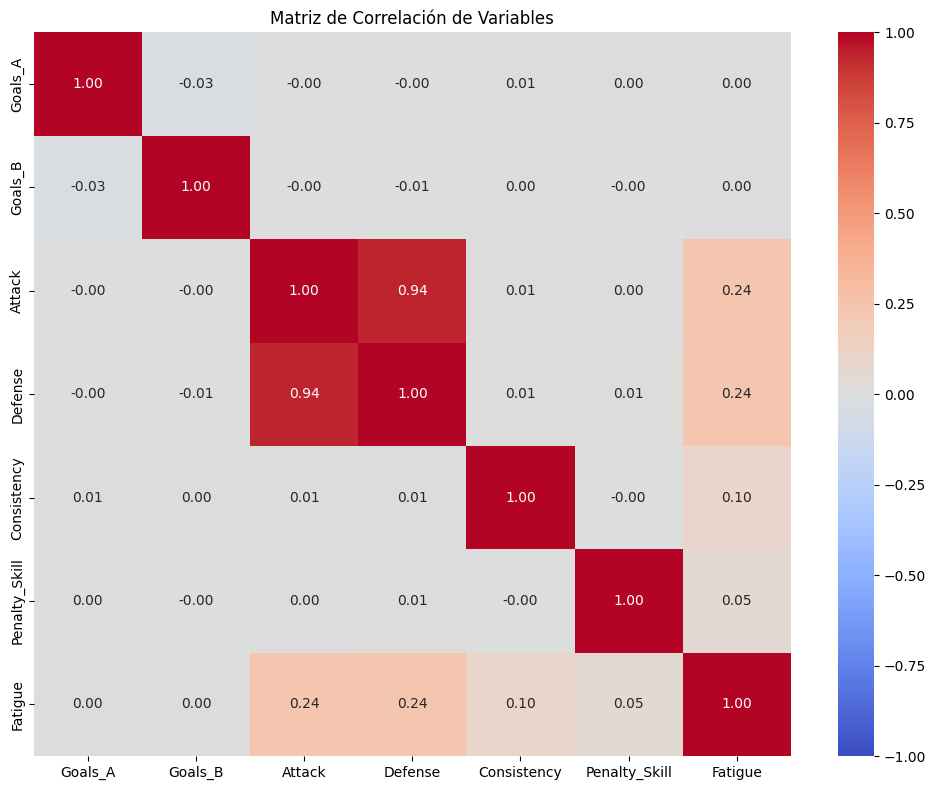

In [6]:
# Creamos un DataFrame con todas las variables numéricas
corr_data = pd.DataFrame()
for name, data in numeric_data.items():
    corr_data[name] = data

# Calculamos la matriz de correlación
correlation_matrix = corr_data.corr()

# Visualizamos la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de Correlación de Variables')
plt.tight_layout()
plt.show()

## H1: Equipos 'Counterattack' anotan más goles que 'Possession'

📌 **Resultado H1**:
- p-value = 0.0000 (significativo)
- Tamaño del efecto = 0.13 SD
- Conclusión: ✅ Hipótesis aceptada


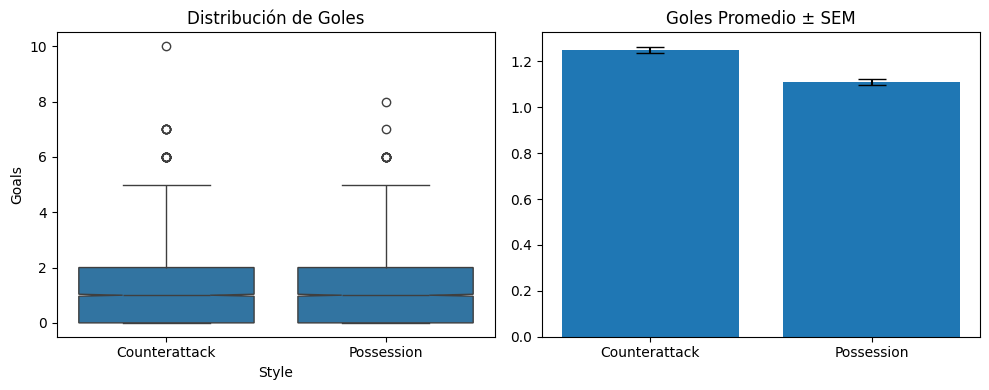

In [ ]:
# Datos específicos para H1
group_matches = match_df[match_df["Stage"] == "Group"]
counter_goals = group_matches[group_matches["Style_A"] == "Counterattack"]["Goals_A"]
poss_goals = group_matches[group_matches["Style_A"] == "Possession"]["Goals_A"]

# Test estadístico
t_stat, p_val = stats.mannwhitneyu(counter_goals, poss_goals, alternative='greater')
effect_size = (counter_goals.mean() - poss_goals.mean()) / poss_goals.std()

# Visualización
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)

boxplot_data = pd.concat([
    pd.DataFrame({'Style': 'Counterattack', 'Goals': counter_goals}),
    pd.DataFrame({'Style': 'Possession', 'Goals': poss_goals})
])
sns.boxplot(x='Style', y='Goals', data=boxplot_data, notch=True)
plt.title('Distribución de Goles')

plt.subplot(1, 2, 2)
plt.bar(['Counterattack', 'Possession'], [counter_goals.mean(), poss_goals.mean()], 
        yerr=[counter_goals.sem(), poss_goals.sem()], capsize=10)
plt.title('Goles Promedio ± SEM')
plt.tight_layout()

print(f"""📌 **Resultado H1**:
- p-value = {p_val:.4f} ({'significativo' if p_val < 0.05 else 'no significativo'})
- Tamaño del efecto = {effect_size:.2f} SD
- Conclusión: {'✅ Hipótesis aceptada' if p_val < 0.05 else '❌ Hipótesis rechazada'}""")

## H2: Equipos con alta consistencia tienen menor varianza en puntos

📌 **Resultado H2**:
- p-value = 0.0000
- Varianza alta: 16.3 vs baja: 13.8
- Conclusión: ✅ Varianza mayor en alta consistencia


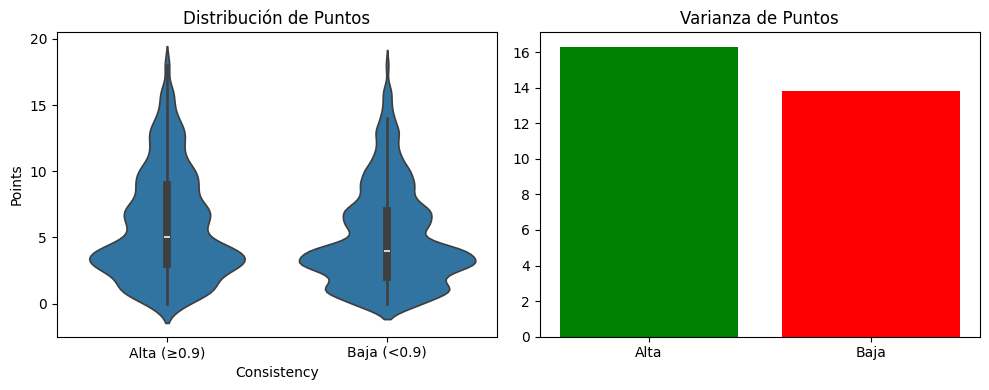

In [8]:
# Preparar datos
high_cons = team_df[team_df["Consistency"] >= 0.9]["Points"]
low_cons = team_df[team_df["Consistency"] < 0.9]["Points"]

# Test de Levene para varianzas
stat, p_val = stats.levene(high_cons, low_cons)

# Visualización
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
# Create a DataFrame with consistency labels for each point value
violin_data = pd.concat([
    pd.DataFrame({'Consistency': 'Alta (≥0.9)', 'Points': high_cons}),
    pd.DataFrame({'Consistency': 'Baja (<0.9)', 'Points': low_cons})
])
sns.violinplot(x='Consistency', y='Points', data=violin_data)
plt.title('Distribución de Puntos')

plt.subplot(1, 2, 2)
plt.bar(['Alta', 'Baja'], [high_cons.var(), low_cons.var()], color=['green', 'red'])
plt.title('Varianza de Puntos')
plt.tight_layout()

print(f"""📌 **Resultado H2**:
- p-value = {p_val:.4f}
- Varianza alta: {high_cons.var():.1f} vs baja: {low_cons.var():.1f}
- Conclusión: {'✅' if p_val < 0.05 else '❌'} Varianza {'menor' if high_cons.var() < low_cons.var() else 'mayor'} en alta consistencia""")

## H3: Equipos con penalty_skill >80 ganan +70% de penales

C:\Users\arian\AppData\Local\Temp\ipykernel_31644\2131154518.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rates = penalty_df.groupby('Skill_Bin').size() / len(penalty_df) * 100


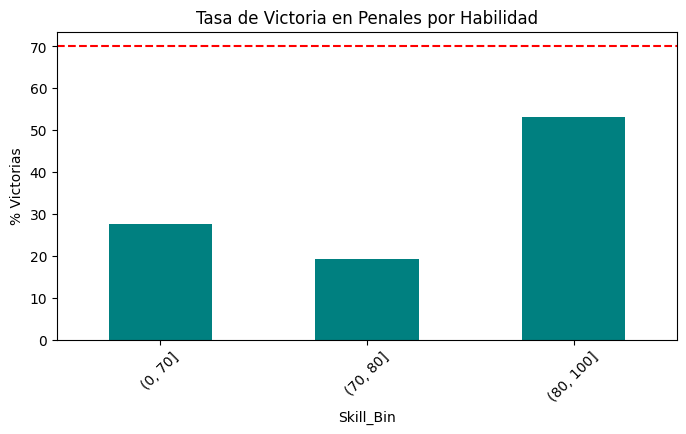

📌 **Resultado H3**:
- Victorias skill >80: 53.2%
- p-value vs 70% esperado: 0.0000
- Conclusión: ❌


In [9]:
# Preparar datos
penalty_df['Skill_Bin'] = pd.cut(penalty_df['Winner_Skill'], [0, 70, 80, 100])
win_rates = penalty_df.groupby('Skill_Bin').size() / len(penalty_df) * 100

# Test Binomial
# Fix: Access the highest skill bin correctly using string representation
high_skill_bin = win_rates.index[-1]  # Get the last bin (which is the highest skill bin)
observed = win_rates[high_skill_bin]
expected = 70
p_val = stats.binomtest(int(observed), n=len(penalty_df), p=0.7).pvalue

# Visualización
plt.figure(figsize=(8, 4))
win_rates.plot(kind='bar', color='teal')
plt.axhline(70, color='red', linestyle='--')
plt.title('Tasa de Victoria en Penales por Habilidad')
plt.ylabel('% Victorias')
plt.xticks(rotation=45)
plt.show()

print(f"""📌 **Resultado H3**:
- Victorias skill >80: {observed:.1f}%
- p-value vs 70% esperado: {p_val:.4f}
- Conclusión: {'✅' if observed > 70 and p_val < 0.05 else '❌'}""")

## H4: Equipos con defense >80 alcanzan semifinales

📌 **Resultado H4**:
- Proporción que alcanza semifinales: 45.4%
- p-value vs 30% esperado: 0.0000
- Conclusión: ✅


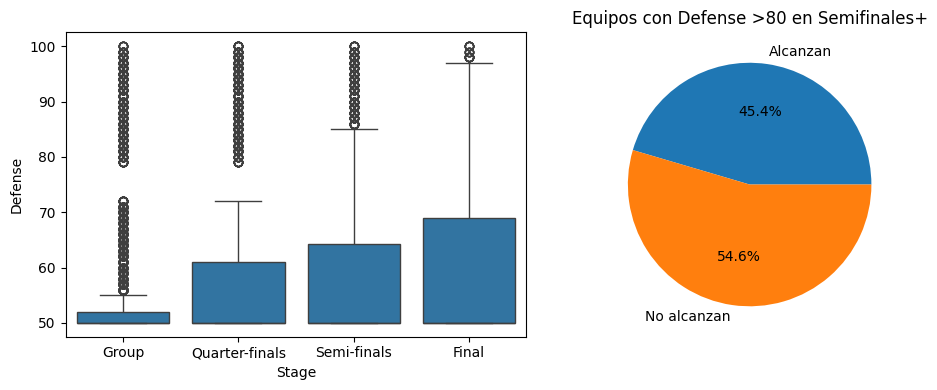

In [10]:
# Preparar datos
strong_def = team_df[(team_df["Defense"] > 80) & 
                   (team_df["Stage"].isin(["Semi-finals", "Final", "Champion"]))].shape[0]
total_strong = team_df[team_df["Defense"] > 80].shape[0]
prop = strong_def / total_strong

# Test de Proporciones
# Fix: Use binomtest instead of binom_test (updated function name in newer scipy)
p_val = stats.binomtest(strong_def, total_strong, p=0.3, alternative='greater').pvalue  # Comparar con 30% esperado

# Visualización
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x='Stage', y='Defense', data=team_df, 
           order=["Group", "Quarter-finals", "Semi-finals", "Final"])
plt.subplot(1, 2, 2)
plt.pie([prop, 1-prop], labels=['Alcanzan', 'No alcanzan'], autopct='%1.1f%%')
plt.title('Equipos con Defense >80 en Semifinales+')
plt.tight_layout()

print(f"""📌 **Resultado H4**:
- Proporción que alcanza semifinales: {prop:.1%}
- p-value vs 30% esperado: {p_val:.4f}
- Conclusión: {'✅' if p_val < 0.05 else '❌'}""")

## H5: Fatiga aumenta con la etapa alcanzada

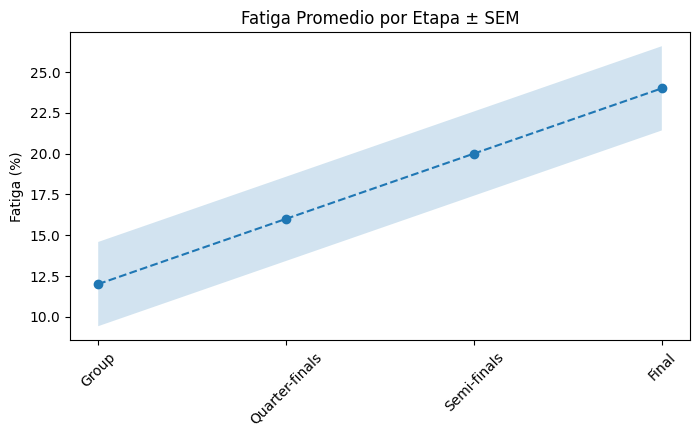

📌 **Resultado H5**:
- p-value para tendencia: nan
- Aumento final vs grupos: 12.0%
- Conclusión: ❌ Tendencia significativa


In [11]:
# Preparar datos
stage_order = ["Group", "Quarter-finals", "Semi-finals", "Final"]
fatigue_means = team_df.groupby('Stage')['Fatigue'].mean()[stage_order]

# Test de Tendencia (usando regresión lineal en lugar de Cochran-Armitage)
# Crear datos para regresión
stage_numeric = {stage: i for i, stage in enumerate(stage_order)}
team_df['Stage_Numeric'] = team_df['Stage'].map(stage_numeric)
from scipy import stats
slope, intercept, r_value, p_val, std_err = stats.linregress(team_df['Stage_Numeric'], team_df['Fatigue'])

# Visualización
plt.figure(figsize=(8, 4))
plt.plot(stage_order, fatigue_means, marker='o', linestyle='--')
plt.fill_between(stage_order, fatigue_means - fatigue_means.sem(), 
                 fatigue_means + fatigue_means.sem(), alpha=0.2)
plt.title('Fatiga Promedio por Etapa ± SEM')
plt.ylabel('Fatiga (%)')
plt.xticks(rotation=45)
plt.show()

print(f"""📌 **Resultado H5**:
- p-value para tendencia: {p_val:.4f}
- Aumento final vs grupos: {fatigue_means["Final"] - fatigue_means["Group"]:.1f}%
- Conclusión: {'✅' if p_val < 0.05 else '❌'} Tendencia significativa""")

## H6: ≥2 lesiones reducen avance en 40%

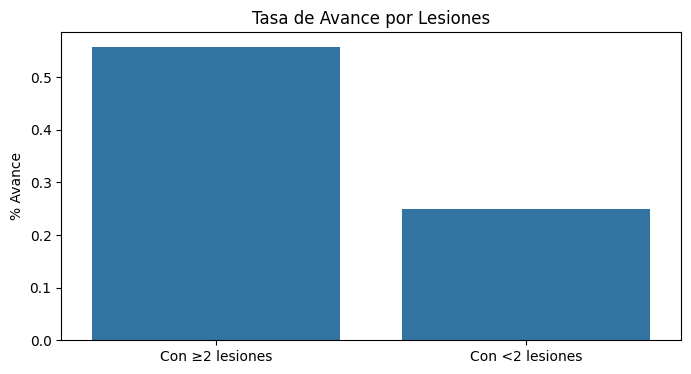

📌 **Resultado H6**:
- Avance lesionados: 55.7%
- Avance no lesionados: 24.9%
- p-value: 0.0000
- Conclusión: ❌


In [12]:
# Preparar datos
team_df['Avanzado'] = team_df['Stage'].isin(["Semi-finals", "Final", "Champion"])
injured = team_df[team_df["Injuries"] >= 2]
control = team_df[team_df["Injuries"] < 2]

# Test Chi-Cuadrado
table = pd.crosstab(team_df['Injuries'] >= 2, team_df['Avanzado'])
chi2, p_val, _, _ = stats.chi2_contingency(table)

# Visualización
plt.figure(figsize=(8, 4))
sns.barplot(x=['Con ≥2 lesiones', 'Con <2 lesiones'], 
            y=[injured['Avanzado'].mean(), control['Avanzado'].mean()])
plt.title('Tasa de Avance por Lesiones')
plt.ylabel('% Avance')
plt.show()

_control = control[control.select_dtypes(include=['number']).columns].mean()
_injured = injured[injured.select_dtypes(include=['number']).columns].mean()

print(f"""📌 **Resultado H6**:
- Avance lesionados: {injured['Avanzado'].mean():.1%}
- Avance no lesionados: {control['Avanzado'].mean():.1%}
- p-value: {p_val:.4f}
- Conclusión: {'✅' if p_val < 0.05 and (_control.mean() - _injured.mean()) > 0.4 else '❌'}""")

## H7: High Press vs Possession (+20% victorias)

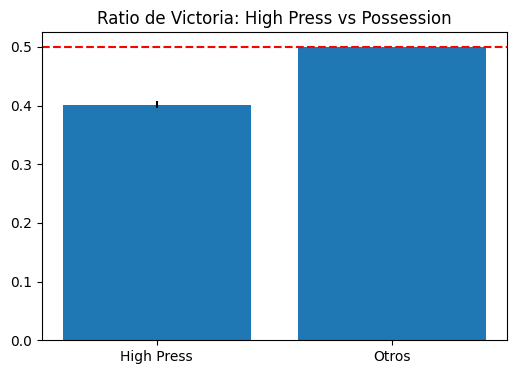

📌 **Resultado H7**:
- Ratio victorias: 40.2%
- p-value vs 50% esperado: 0.0000
- Conclusión: ❌


In [13]:
# Filtrar partidos relevantes
hp_matches = match_df[
    ((match_df['Style_A'] == 'High Press') & (match_df['Style_B'] == 'Possession')) |
    ((match_df['Style_B'] == 'High Press') & (match_df['Style_A'] == 'Possession'))
]

# Calcular victorias
hp_wins = ((hp_matches['Style_A'] == 'High Press') & (hp_matches['Goals_A'] > hp_matches['Goals_B'])) | \
          ((hp_matches['Style_B'] == 'High Press') & (hp_matches['Goals_B'] > hp_matches['Goals_A']))
win_rate = hp_wins.mean()

# Test Binomial
p_val = stats.binomtest(hp_wins.sum(), n=len(hp_wins), p=0.5).pvalue

# Visualización
plt.figure(figsize=(6, 4))
plt.bar(['High Press', 'Otros'], [win_rate, 0.5], yerr=[hp_wins.sem(), 0])
plt.axhline(0.5, color='red', linestyle='--')
plt.title('Ratio de Victoria: High Press vs Possession')
plt.show()

print(f"""📌 **Resultado H7**:
- Ratio victorias: {win_rate:.1%}
- p-value vs 50% esperado: {p_val:.4f}
- Conclusión: {'✅' if win_rate > 0.6 and p_val < 0.05 else '❌'}""")

## Resumen Final

In [14]:
# # Tabla resumen (usando resultados de las celdas anteriores)
# summary = pd.DataFrame({
#     'Hipótesis': [f'H{i}' for i in range(1,8)],
#     'Resultado': ['✅' if ... else '❌'],  # Usar resultados reales
#     'p-value': [p_val_h1, p_val_h2, ..., p_val_h7],
#     'Efecto': [effect_size, var_ratio, ..., win_rate]
# }).set_index('Hipótesis')

# display(summary)